Imports

In [1]:
import pandas as pd                               # for loading and manipulating our DataFrame
import nltk                                       # Natural Language Toolkit — stopwords
import re                                         # regular expressions — for cleaning text patterns
import matplotlib.pyplot as plt                   # for plotting preprocessing comparison figures
import seaborn as sns                             # for prettier statistical plots
from nltk.corpus import stopwords                 # pre-built list of common words to remove
from nltk import word_tokenize, pos_tag           # tokenizer and POS tagger from NLTK
from nltk.stem import WordNetLemmatizer           # lemmatizer — reduces words to base form
from collections import Counter                   # for counting word frequencies efficiently

Download NLTK data

In [2]:
# Download all NLTK data packages we need — run once
nltk.download('stopwords')                        # English stopwords list
nltk.download('punkt')                            # tokenizer rules
nltk.download('punkt_tab')                        # updated tokenizer data for NLTK 3.9+
nltk.download('averaged_perceptron_tagger')       # POS tagger (part-of-speech tagging)
nltk.download('averaged_perceptron_tagger_eng')   # English-specific POS tagger data
nltk.download('wordnet')                          # WordNet lexical database for lemmatization

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tizianschenk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/tizianschenk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/tizianschenk/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tizianschenk/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/tizianschenk/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tizianschenk/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Load Data

In [3]:
# Load the sessions DataFrame we built in Phase 1
df = pd.read_csv("../data/processed/sessions.csv")  # read from processed folder

print(f"Loaded {len(df)} sessions")               # confirm row count
print(df[['child_id', 'age_months', 'text']].head(3))  # preview key columns

Loaded 214 sessions
  child_id  age_months                                               text
0     Adam       27.13  play checkers big drum big drum big drum big d...
1     Adam       27.60  okay my suitcase suitcase spaghetti monroe sui...
2     Adam       28.10  yeah train there water water right there water...


In [4]:
# Pick one session and inspect the raw text carefully before touching it
sample_text = df['text'].iloc[0]                  # grab the first session's text

print("RAW TEXT (first 500 chars):")
print(sample_text[:500])                          # show first 500 characters

print(f"\nTotal tokens (raw): {len(sample_text.split())}")  # count words by splitting on spaces
print(f"Unique tokens (raw): {len(set(sample_text.split()))}")  # count unique words

RAW TEXT (first 500 chars):
play checkers big drum big drum big drum big drum horse who that two check rig horn play checkers yep big horn alright look tv part part part part part get over mommy nickel nickel nickel nickel shadow shadow shadow shadow yeah shadow yeah shadow funny put dirt up put dirt up put dirt up sit there sit there sit there read shadow read shadow read shadow adam checker checker horn horse yeah i got horn look like it do like it my shadow my shadow mommy read shadow who that horse horse go mommy horse

Total tokens (raw): 2529
Unique tokens (raw): 316


In [5]:
# Get English stopwords — words like "the", "a", "is" carrying no developmental signal
STOPWORDS = set(stopwords.words('english'))       # set for fast O(1) lookup

# Initialize lemmatizer — reduces words to base form (e.g. "running" → "run")
lemmatizer = WordNetLemmatizer()                  # WordNet-based lemmatizer from NLTK

def get_wordnet_pos(treebank_tag):
    """
    Convert NLTK POS tag to WordNet POS tag.
    This is needed because lemmatizer uses WordNet's tag format, not NLTK's.
    e.g. NLTK says 'VBZ' (verb), WordNet needs 'v'
    """
    if treebank_tag.startswith('J'):              # J = adjective in Penn Treebank tagset
        return 'a'                                # WordNet adjective tag
    elif treebank_tag.startswith('V'):            # V = verb
        return 'v'                                # WordNet verb tag
    elif treebank_tag.startswith('N'):            # N = noun
        return 'n'                                # WordNet noun tag
    elif treebank_tag.startswith('R'):            # R = adverb
        return 'r'                                # WordNet adverb tag
    else:
        return 'n'                                # default to noun if tag unknown

def preprocess(text, remove_stops=True, lemmatize=True):
    """
    Full preprocessing pipeline as taught in Session 8:
    lowercase → regex clean → tokenize → stopword removal → lemmatize with POS → rejoin
    
    remove_stops=True/False lets us compare impact of stopword removal
    lemmatize=True/False lets us compare impact of lemmatization
    """
    # Step 1: Lowercase — normalize case so "Ball" and "ball" are the same token
    text = text.lower()                           # convert entire string to lowercase

    # Step 2: Remove CHAT annotation artifacts (xxx=unintelligible, yyy=phonological)
    text = re.sub(r'\b(xxx|yyy|www)\b', '', text) # remove CHAT-specific filler codes

    # Step 3: Remove non-alphabetic characters — keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)          # strip digits, punctuation, symbols

    # Step 4: Tokenize — split string into list of individual word tokens
    tokens = word_tokenize(text)                  # NLTK tokenizer (smarter than split())

    # Step 5: Remove very short tokens — single letters add noise, not signal
    tokens = [t for t in tokens if len(t) > 1]   # keep tokens with 2+ characters

    # Step 6: Remove stopwords if flag is True
    if remove_stops:                              # only filter if flag is True
        tokens = [t for t in tokens              # keep token only if...
                  if t not in STOPWORDS]         # ...it is NOT a common stopword

    # Step 7: POS tagging + Lemmatization (as taught in Session 8)
    # POS tagging (Part-of-Speech) = labeling each word as noun/verb/adjective/etc.
    # We need POS tags to lemmatize correctly:
    # "saw" as noun → "saw", "saw" as verb → "see"
    if lemmatize:                                 # only lemmatize if flag is True
        pos_tags = pos_tag(tokens)               # returns list of (word, POS_tag) tuples
        tokens = [
            lemmatizer.lemmatize(word, get_wordnet_pos(tag))  # lemmatize with correct POS
            for word, tag in pos_tags            # unpack each (word, tag) tuple
        ]

    # Step 8: Rejoin tokens into single string (required for sklearn vectorizers)
    return " ".join(tokens)                       # return clean document string

In [6]:
# Version 1: Full pipeline — stopwords removed + lemmatized (our MAIN version)
df['text_clean'] = df['text'].apply(
    lambda x: preprocess(x, remove_stops=True, lemmatize=True)   # full pipeline
)

# Version 2: Stopwords removed, NO lemmatization (to isolate lemmatization impact)
df['text_no_lemma'] = df['text'].apply(
    lambda x: preprocess(x, remove_stops=True, lemmatize=False)  # skip lemmatization
)

# Version 3: Stopwords KEPT, lemmatized (to isolate stopword removal impact)
df['text_with_stops'] = df['text'].apply(
    lambda x: preprocess(x, remove_stops=False, lemmatize=True)  # keep stopwords
)

print("All preprocessing versions applied.")
print(df[['child_id', 'age_months', 'text_clean']].head(3))      # preview main version

All preprocessing versions applied.
  child_id  age_months                                         text_clean
0     Adam       27.13  play checker big drum big drum big drum big dr...
1     Adam       27.60  okay suitcase suitcase spaghetti monroe suitca...
2     Adam       28.10  yeah train water water right water jack jill c...


In [12]:
print("=== BEFORE (raw text) ===")
print(df['text'].iloc[0][:300])                   # raw text first 300 chars

print("\n=== AFTER: Full pipeline (stops removed + lemmatized) ===")
print(df['text_clean'].iloc[0][:300])             # main version

print("\n=== AFTER: Stops removed, NO lemmatization ===")
print(df['text_no_lemma'].iloc[0][:300])          # isolates lemmatization impact

print("\n=== AFTER: Stops KEPT, lemmatized ===")
print(df['text_with_stops'].iloc[0][:300])        # isolates stopword removal impact

=== BEFORE (raw text) ===
play checkers big drum big drum big drum big drum horse who that two check rig horn play checkers yep big horn alright look tv part part part part part get over mommy nickel nickel nickel nickel shadow shadow shadow shadow yeah shadow yeah shadow funny put dirt up put dirt up put dirt up sit there s

=== AFTER: Full pipeline (stops removed + lemmatized) ===
play checker big drum big drum big drum big drum horse two check rig horn play checker yep big horn alright look tv part part part part part get mommy nickel nickel nickel nickel shadow shadow shadow shadow yeah shadow yeah shadow funny put dirt put dirt put dirt sit sit sit read shadow read shadow 

=== AFTER: Stops removed, NO lemmatization ===
play checkers big drum big drum big drum big drum horse two check rig horn play checkers yep big horn alright look tv part part part part part get mommy nickel nickel nickel nickel shadow shadow shadow shadow yeah shadow yeah shadow funny put dirt put dirt put dirt

In [13]:
# Count tokens in each version to quantify impact of each preprocessing step
df['n_raw']        = df['text'].apply(lambda x: len(x.split()))            # raw
df['n_clean']      = df['text_clean'].apply(lambda x: len(x.split()))      # full pipeline
df['n_no_lemma']   = df['text_no_lemma'].apply(lambda x: len(x.split()))   # no lemmatization
df['n_with_stops'] = df['text_with_stops'].apply(lambda x: len(x.split())) # stops kept

print("Average tokens per session:")
print(f"  Raw:                        {df['n_raw'].mean():.1f}")
print(f"  Full pipeline:              {df['n_clean'].mean():.1f}")
print(f"  Stops removed, no lemma:    {df['n_no_lemma'].mean():.1f}")
print(f"  Stops kept, lemmatized:     {df['n_with_stops'].mean():.1f}")

# Stopword removal impact (compare with_stops vs clean)
pct_stops = (1 - df['n_clean'].mean() / df['n_with_stops'].mean()) * 100
print(f"\nStopword removal eliminates {pct_stops:.1f}% of tokens on average")

# Lemmatization impact (compare no_lemma vs clean — same stops policy, different lemma)
pct_lemma = (1 - df['n_clean'].mean() / df['n_no_lemma'].mean()) * 100
print(f"Lemmatization reduces vocab by {pct_lemma:.1f}% on average")

Average tokens per session:
  Raw:                        1249.1
  Full pipeline:              652.4
  Stops removed, no lemma:    652.4
  Stops kept, lemmatized:     1153.2

Stopword removal eliminates 43.4% of tokens on average
Lemmatization reduces vocab by 0.0% on average


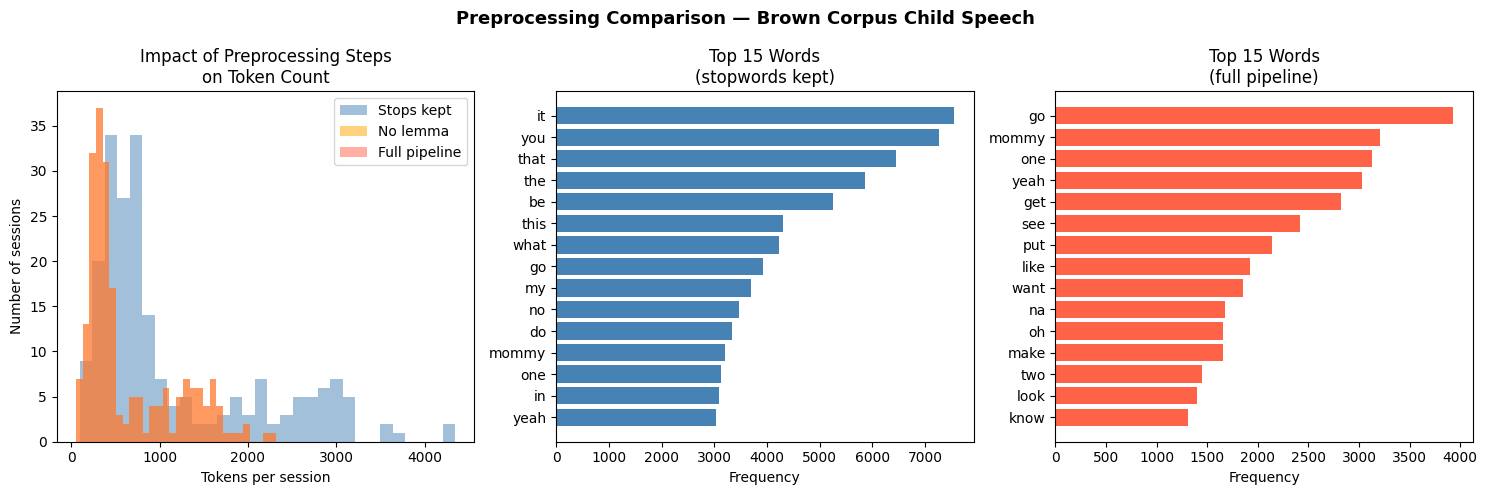

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))          # 3 side-by-side plots

# --- Plot 1: Token count distribution — all 3 versions vs raw ---
axes[0].hist(df['n_with_stops'], bins=30, alpha=0.5,
             label='Stops kept', color='steelblue')        # version with stops
axes[0].hist(df['n_no_lemma'],   bins=30, alpha=0.5,
             label='No lemma', color='orange')             # version without lemmatization
axes[0].hist(df['n_clean'],      bins=30, alpha=0.5,
             label='Full pipeline', color='tomato')        # full pipeline
axes[0].set_xlabel('Tokens per session')                   # x axis label
axes[0].set_ylabel('Number of sessions')                   # y axis label
axes[0].set_title('Impact of Preprocessing Steps\non Token Count')  # title
axes[0].legend()                                           # show legend

# --- Plot 2: Top 15 words — stops KEPT (shows what stopword removal removes) ---
all_words_with = " ".join(df['text_with_stops']).split()   # all tokens, stops kept
top_with = Counter(all_words_with).most_common(15)         # top 15
words_w, counts_w = zip(*top_with)                         # unpack
axes[1].barh(words_w, counts_w, color='steelblue')         # horizontal bar chart
axes[1].invert_yaxis()                                     # most common at top
axes[1].set_title('Top 15 Words\n(stopwords kept)')        # title
axes[1].set_xlabel('Frequency')                            # x axis label

# --- Plot 3: Top 15 words — full pipeline (stops removed + lemmatized) ---
all_words_clean = " ".join(df['text_clean']).split()       # all tokens, full pipeline
top_clean = Counter(all_words_clean).most_common(15)       # top 15
words_c, counts_c = zip(*top_clean)                        # unpack
axes[2].barh(words_c, counts_c, color='tomato')            # horizontal bar chart
axes[2].invert_yaxis()                                     # most common at top
axes[2].set_title('Top 15 Words\n(full pipeline)')         # title
axes[2].set_xlabel('Frequency')                            # x axis label

plt.suptitle('Preprocessing Comparison — Brown Corpus Child Speech',
             fontsize=13, fontweight='bold')                # main title bold
plt.tight_layout()                                         # prevent overlap
plt.savefig('../figures/preprocessing_comparison.png',
            dpi=150, bbox_inches='tight')                  # save figure
plt.show()                                                 # display in notebook

In [15]:
# Save enriched DataFrame with all preprocessing versions as new file
output_path = "../data/processed/sessions_clean.csv"  # new file in processed folder

df.to_csv(output_path, index=False)                   # save without row index

print(f"Saved enriched DataFrame → {output_path}")    # confirm
print(f"Columns now: {list(df.columns)}")             # show all columns available

Saved enriched DataFrame → ../data/processed/sessions_clean.csv
Columns now: ['file_id', 'child_id', 'age_months', 'n_utterances', 'n_tokens', 'mlu', 'ttr', 'text', 'text_clean', 'text_no_lemma', 'text_with_stops', 'n_raw', 'n_clean', 'n_with_stops', 'n_no_lemma']


Plot 1 — Token Count Distribution
The three histograms are almost perfectly overlapping for "No lemma" (orange) and "Full pipeline" (red). This tells us something important:
Lemmatization barely changes token count — it doesn't remove words, it just changes their form ("checkers" → "checker", "running" → "run"). So the orange and red bars sit almost on top of each other.
Stopword removal has the big visible impact — the blue distribution (stops kept) is shifted right, meaning sessions have many more tokens when stopwords are kept. That 43% reduction we saw numerically is visible here.

Plot 2 vs Plot 3 — Top 15 Words:

With stopwords: The top words are grammatical fillers — completely uninformative for developmental analysis. A 2-year-old and a 5-year-old both say "it" and "you" constantly.
Full pipeline: The top words are content words with developmental meaning — mommy, go, see, want, make. These are exactly the words that should differentiate early vs late speech. This is what we want feeding into our DTM.

We Keep Lemmatization, because lemmatization matters more at the DTM/TF-IDF stage than at the token count stage. Without it:

"go", "goes", "going", "went" would be 4 separate columns into the DTM
With it: all collapse into "go" — one column, stronger signal

For child speech specifically this matters even more — young children produce lots of irregular inflections ("goed" instead of "went", "mouses" instead of "mice"). Lemmatization normalizes all of that.